<p class="eyebrow">Compute markets / RTX 3090 / Vast.ai</p>

# Available, at what price?
<p class="subtitle">The full February–August 2026 history, in two charts.</p>

An availability index should tell a buyer how much qualifying compute is visible
**within their budget**. A price index should distinguish changes in the listings
on screen from changes in the prices of the same machines.

<p class="scope">Verified listings · reliability ≥99% · all recorded locations</p>

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'indices.py').exists():
    ROOT = ROOT / 'modelling' / 'rtx3090'
sys.path.insert(0, str(ROOT))
from indices import clean_observations, select_segment, scan_market, daily_market, weekly_market, weekly_machine_quotes, chained_matched_prices
DATA, OUT = ROOT.parent / 'vast-market' / 'data', ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
BUDGET = .20
PRICE_BASE_WEEK = '2026-05-04'  # Same price reference as the earlier event-window view.
PAPER, INK, MUTED = '#faf7f0', '#4b2738', '#8c6f79'
plt.rcParams.update({'font.family':'DejaVu Sans', 'font.size':10,
    'figure.facecolor':PAPER, 'axes.facecolor':PAPER, 'savefig.facecolor':PAPER,
    'text.color':INK, 'axes.labelcolor':MUTED, 'xtick.color':MUTED, 'ytick.color':MUTED,
    'axes.edgecolor':MUTED, 'axes.spines.top':False, 'axes.spines.right':False,
    'axes.spines.left':False, 'axes.spines.bottom':False, 'axes.grid':False,
    'legend.frameon':False, 'svg.fonttype':'none'})

def say(text):
    display(Markdown(text.replace('$', '&#36;')))

def canvas(unit, mobile=False):
    fig, ax = plt.subplots(figsize=(4.1,4.5) if mobile else (9,4.4))
    fig.subplots_adjust(left=.11 if mobile else .065, right=.95,
                        bottom=.16, top=.73 if mobile else .79)
    fig.text(.11 if mobile else .065, .96, unit, va='top',
             fontfamily='DejaVu Sans Mono', fontsize=9, color=MUTED)
    ax.set_xlim(window.index.min()-pd.Timedelta(days=2), window.index.max()+pd.Timedelta(days=6))
    ax.set_xticks(window.index[::4])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='both', length=0, pad=9, labelsize=8 if mobile else 10)
    ax.yaxis.grid(True, color=INK, alpha=.12, linewidth=.65)
    ax.set_axisbelow(True)
    fig.text(.11 if mobile else .065, .025, 'Week beginning · 2026 · UTC',
             fontfamily='DejaVu Sans Mono', fontsize=8, color=MUTED)
    return fig, ax

def finish(fig, ax, name, mobile):
    ax.legend(loc='lower left', bbox_to_anchor=(0,1.015), borderaxespad=0,
              ncol=1 if mobile else 2, fontsize=9, handlelength=2.5, columnspacing=2)
    suffix = '_mobile' if mobile else ''
    fig.savefig(OUT / f'{name}{suffix}.png', dpi=180)
    fig.savefig(OUT / f'{name}{suffix}.svg')
    if not mobile:
        display(fig)
    plt.close(fig)

hashes = {name:hashlib.sha256((DATA/name).read_bytes()).hexdigest()
          for name in ['snapshots.parquet','snapshot_meta.parquet']}
assert hashes == json.loads((DATA.parent/'input_hashes.json').read_text())
raw, meta = [pd.read_parquet(DATA/name) for name in ['snapshots.parquet','snapshot_meta.parquet']]
clean, scans, audit = clean_observations(raw, meta)
segment = select_segment(clean)
market = scan_market(segment, scans, budget=BUDGET)
daily = daily_market(market, minimum_scans=120)
weekly, bases = weekly_market(daily, minimum_days=5)
quotes = weekly_machine_quotes(segment, daily)
matched, pairs = chained_matched_prices(quotes, weekly, base_week=PRICE_BASE_WEEK)
window = weekly.join(matched)
window['available_price_index'] = 100 * window.available_ask / window.loc[PRICE_BASE_WEEK,'available_ask']
assert window.usable_days.ge(5).all()
assert window[['availability_index','affordable_availability_index','available_price_index','matched_price_index']].notna().all().all()
assert pairs.groupby(['week','machine_id']).size().eq(1).all()
recovery, peak = window.loc['2026-06-01'], window.loc['2026-05-25']
minimum_matches, maximum_matches = matched.matched_machines.dropna().agg(['min','max']).astype(int)
balanced_count = len(quotes.pivot(index='configuration',columns='week',values='price').reindex(columns=window.index).dropna())

## 01 / Availability at a fixed price

In the week of **June 1**, visible availability was back to **90%** of March's level. Availability at **≤ &#36;0.20/hour** was still only **2.2%** of its March level.

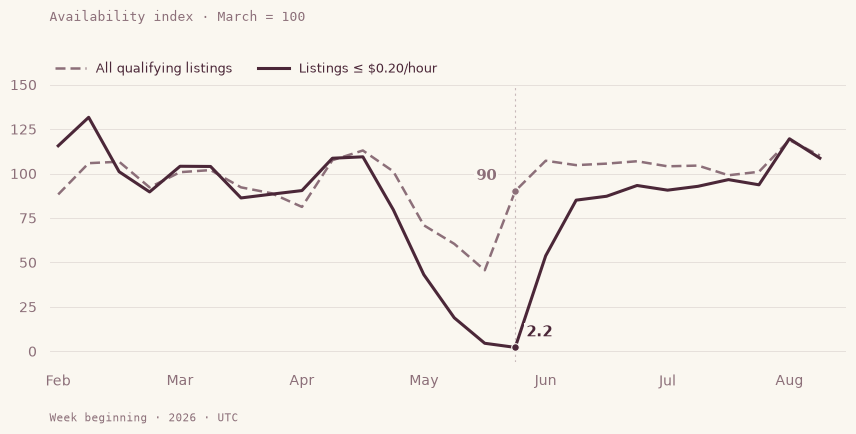

<p class="caption">Each series is relative to its own March level. The June 1 week averaged 18.2 qualifying listings per scan, of which 0.33 cost ≤ &#36;0.20/hour.</p>

**More listings did not yet mean more affordable compute.** The price ceiling makes that gap visible; an unfiltered availability count misses it.

In [2]:
say(f"In the week of **June 1**, visible availability was back to **{recovery.availability_index:.0f}%** "
    f"of March's level. Availability at **≤ ${BUDGET:.2f}/hour** was still only "
    f"**{recovery.affordable_availability_index:.1f}%** of its March level.")
for mobile in [False, True]:
    fig, ax = canvas('Availability index · March = 100', mobile)
    ax.plot(window.index, window.availability_index, color=MUTED, lw=1.8,
            ls=(0,(4,2)), label='All qualifying listings')
    ax.plot(window.index, window.affordable_availability_index, color=INK, lw=2.2,
            label=f'Listings ≤ ${BUDGET:.2f}/hour')
    ax.set_ylim(-6,150)
    ax.set_yticks([0,25,50,75,100,125,150])
    point = pd.Timestamp('2026-06-01',tz='UTC')
    ax.axvline(point, color=MUTED, alpha=.45, ls=(0,(2,3)), lw=.8)
    for value, color, text in [(recovery.availability_index,MUTED,f'{recovery.availability_index:.0f}'),
            (recovery.affordable_availability_index,INK,f'{recovery.affordable_availability_index:.1f}')]:
        ax.scatter([point],[value],s=30,color=color,zorder=4,edgecolor=PAPER,linewidth=.8)
        ax.annotate(text, (point,value), xytext=(-28,8) if value>50 else (8,8), textcoords='offset points',
                    color=color, fontsize=11, fontweight='bold',
                    bbox=dict(facecolor=PAPER,edgecolor='none',pad=1.5))
    finish(fig,ax,'01_availability',mobile)
say(f'<p class="caption">Each series is relative to its own March level. '
    f'The June 1 week averaged {recovery.availability:.1f} qualifying listings per scan, '
    f'of which {recovery.affordable_availability:.2f} cost ≤ ${BUDGET:.2f}/hour.</p>')
say('**More listings did not yet mean more affordable compute.** '
    'The price ceiling makes that gap visible; an unfiltered availability count misses it.')

## 02 / Available quotes and matched prices

The available asking-price index rose **131%** from early to late May. Matching the same machines between consecutive weeks gives a **55%** rise over that period. Both series cover the full collection history.

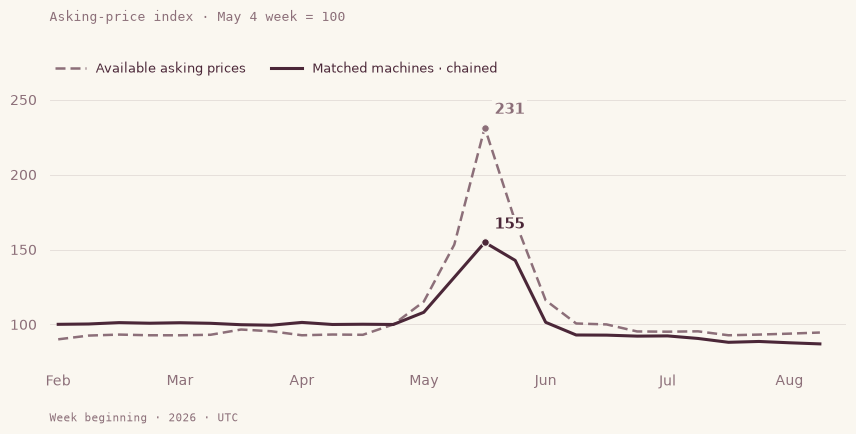

<p class="caption">26 weeks · 46–106 matched machines per weekly link. The matched set can change each week; reported host, location and hardware attributes must match within each pair. Both curves show asking prices.</p>

**The rise included repricing of the same machines.** Changing listings also affects the available-price measure, but the gap between these curves is not an exact estimate of that effect: the matched sample changes and chaining can accumulate drift.

In [3]:
say(f"The available asking-price index rose **{peak.available_price_index-100:.0f}%** from early to late May. "
    f"Matching the same machines between consecutive weeks gives a **{peak.matched_price_index-100:.0f}%** "
    "rise over that period. Both series cover the full collection history.")
for mobile in [False, True]:
    fig, ax = canvas('Asking-price index · May 4 week = 100', mobile)
    ax.plot(window.index, window.available_price_index, color=MUTED, lw=1.8,
            ls=(0,(4,2)), label='Available asking prices')
    ax.plot(window.index, window.matched_price_index, color=INK, lw=2.2,
            label='Matched machines · chained')
    ax.set_ylim(75,260)
    ax.set_yticks([100,150,200,250])
    point = pd.Timestamp('2026-05-25',tz='UTC')
    for value,color in [(peak.available_price_index,MUTED),(peak.matched_price_index,INK)]:
        ax.scatter([point],[value],s=30,color=color,zorder=4,edgecolor=PAPER,linewidth=.8)
        ax.annotate(f'{value:.0f}',(point,value),xytext=(7,10),textcoords='offset points',
                    color=color,fontsize=11,fontweight='bold',
                    bbox=dict(facecolor=PAPER,edgecolor='none',pad=1.5))
    finish(fig,ax,'02_prices',mobile)
say(f'<p class="caption">{len(window)} weeks · {minimum_matches}–{maximum_matches} matched machines per weekly link. '
    'The matched set can change each week; reported host, location and hardware attributes must match within each pair. '
    'Both curves show asking prices.</p>')
say('**The rise included repricing of the same machines.** Changing listings also affects the available-price '
    'measure, but the gap between these curves is not an exact estimate of that effect: '
    'the matched sample changes and chaining can accumulate drift.')

<p class="measurement-note">These are observed listings in a capped search sample, not total marketplace
capacity. The source omits GPU quantity; prices retain its USD/hour unit.</p>

<p class="downloads"><a href="rtx3090_market.ipynb">Open notebook ↗</a>
· <a href="outputs/study_weekly.csv">Chart data</a>
· <a href="https://www.adamsioud.com/exemplars/compute/feeling_the_compute.html#financialization">Original availability thesis</a></p>

## Methodology and source audit

**Source and scope.** [Marcus Lammers' Vast RTX 3090 dataset](https://huggingface.co/datasets/MarcusLammers/vast-rtx3090-market-6mo)
covers February–August 2026 at approximately ten-minute intervals. We clean the
full collection and plot every validated weekly observation, using March as the
availability reference. Only verified listings with reliability ≥99%
and positive CPU cores/RAM qualify. All recorded locations are pooled.

**Availability.** Count qualifying listings in each successful scan; count them
again with the illustrative, fixed $0.20/hour ceiling. Average scans within each
day, then give usable days equal weight within each week. Divide each series by
its own March mean and multiply by 100. Index 100 means its March level, not 100
listings, 100 GPUs, or 100% of marketplace supply. Require at least 120 valid scans
per day and five usable days per week. Failed scans are unknown, never zero.

**Available asking prices.** Take the median qualifying quote per scan, the median
of those scan medians per day, then the median across usable days per week.
Divide by the May 4 week's value and multiply by 100. The listings and their mix
can change every scan. These are not executed transaction prices.

**Matched asking prices.** Match machine ID, host ID, country, region, GPU RAM,
CPU cores and CPU RAM. A configuration needs at least three usable days and 36
observations in each of the two weeks being compared. Take its daily median
quote, then its weekly median. For each consecutive pair of weeks, take the
geometric mean of matched machines' price ratios. Multiply these weekly factors
together to form a chained Jevons index; rebase the May 4 week to 100. Each machine
has equal weight within a link. The matched set can change between links. Require
at least 20 pairs and adequate scan coverage in both weeks; a missing link breaks
the index. Never interpolate, bridge a missing week, or carry quotes forward.

**Interpretation.** A fixed basket across all 26 weeks would retain only two
configurations. Adjacent-week matching uses more of the data but still selects
visible machines. It tracks matched quote changes, not an unchanged six-month
basket. Changing matched samples can cause chain drift: prices returning to their
initial levels do not guarantee the index returns to 100. GPU quantity,
contract terms and other unobserved attributes cannot be held constant. The two
price curves use different samples and aggregation, so their difference cannot
be assigned entirely to composition. Neither figure establishes why an offer
disappeared, whether it was rented, or what caused the May episode.

**Collection limit.** The source returns at most 64 offers per scan. Unknown
ranking and excluded results mean that these counts measure observed listing
depth. Filtering after collection does not remove this ceiling. March and the
event weeks can have different truncation; that limits market-wide comparisons.

**Reproduce.** Run `python run_notebook.py` from this folder after installing
`requirements.txt`. The editable source is `study.py`; the notebook contains
executed code and both charts. Raw inputs remain unchanged in
`../vast-market/data/`, checked against their pinned SHA-256 hashes.
[Matched quotes](outputs/matched_quotes.csv) · [Full weekly series](outputs/weekly_market.csv)
· [Audit and parameters](outputs/summary.json)

In [4]:
say(f"**Audit.** {audit['source_rows']:,} source observations; {audit['rows_quarantined_bad_scan']:,} "
    f"rows quarantined because their scans fail validation. {audit['valid_scans']:,} valid scans; "
    f"{audit['failed_scan_attempts']} failed attempts; {audit['capped_share_of_valid_scans']:.1%} "
    f"of valid scans hit 64 results. {len(segment):,} qualifying observations. The charts include "
    f"all {len(window)} weekly observations from {window.index.min():%B %d} to {window.index.max():%B %d}. "
    "The first and last weeks have six and five usable days respectively. Source observations run "
    f"from {raw.timestamp.min():%B %d} to {raw.timestamp.max():%B %d}; dates without validated "
    "scan metadata or adequate daily coverage remain outside the indices.")
daily.to_csv(OUT/'daily_market.csv')
weekly.to_csv(OUT/'weekly_market.csv')
window.to_csv(OUT/'study_weekly.csv')
pairs.to_csv(OUT/'matched_quotes.csv',index=False)
quotes.to_csv(OUT/'weekly_machine_quotes.csv',index=False)
matched.to_csv(OUT/'matched_weekly_links.csv')
summary = dict(audit=audit,input_sha256=hashes,availability_march_base=bases,
    parameters=dict(budget_usd_hour=BUDGET,verified=True,minimum_reliability=.99,
        minimum_scans_day=120,minimum_days_week=5,minimum_matched_days_week=3,
        minimum_matched_observations_week=36,minimum_pairs=20,price_base_week=PRICE_BASE_WEEK,
        first_week=str(window.index.min().date()),last_week=str(window.index.max().date())),
    matched_method='Chained adjacent-week Jevons; equally weighted machines within each link',
    matched_machines_per_link_min=int(minimum_matches),matched_machines_per_link_max=int(maximum_matches),
    configurations_visible_every_week=int(balanced_count),
    june1_availability_index=float(recovery.availability_index),
    june1_budget_availability_index=float(recovery.affordable_availability_index),
    may25_available_price_index=float(peak.available_price_index),
    may25_matched_price_index=float(peak.matched_price_index),
    units='Source USD/hour; GPU quantity not supplied')
_ = (OUT/'summary.json').write_text(json.dumps(summary,indent=2))

**Audit.** 1,624,024 source observations; 7,552 rows quarantined because their scans fail validation. 25,948 valid scans; 7 failed attempts; 88.0% of valid scans hit 64 results. 505,649 qualifying observations. The charts include all 26 weekly observations from February 16 to August 10. The first and last weeks have six and five usable days respectively. Source observations run from February 13 to August 15; dates without validated scan metadata or adequate daily coverage remain outside the indices.